In [85]:
# Main libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict 
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
# SMOTE
from imblearn.over_sampling import SMOTE

import pickle

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Removing Unnecessary Columns

In [6]:
df.drop('customerID', axis=1, inplace=True)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Exploring Unique Values in Categorical Columns

In [7]:
features = ['tenure', 'MonthlyCharges', 'TotalCharges']
for i in df.columns:
    if i not in features:
        print(i, ':', df[i].unique())
        print('*'*20)

gender : ['Female' 'Male']
********************
SeniorCitizen : [0 1]
********************
Partner : ['Yes' 'No']
********************
Dependents : ['No' 'Yes']
********************
PhoneService : ['No' 'Yes']
********************
MultipleLines : ['No phone service' 'No' 'Yes']
********************
InternetService : ['DSL' 'Fiber optic' 'No']
********************
OnlineSecurity : ['No' 'Yes' 'No internet service']
********************
OnlineBackup : ['Yes' 'No' 'No internet service']
********************
DeviceProtection : ['No' 'Yes' 'No internet service']
********************
TechSupport : ['No' 'Yes' 'No internet service']
********************
StreamingTV : ['No' 'Yes' 'No internet service']
********************
StreamingMovies : ['No' 'Yes' 'No internet service']
********************
Contract : ['Month-to-month' 'One year' 'Two year']
********************
PaperlessBilling : ['Yes' 'No']
********************
PaymentMethod : ['Electronic check' 'Mailed check' 'Bank transfer (automati

### Check Missing Values

In [8]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Viewing TotalCharges values

In [9]:
df['TotalCharges'].values

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

In [10]:
# some spaces in TotalCharges
df[df['TotalCharges'] == ' ']

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [11]:
len(df[df['TotalCharges'] == ' '])

11

In [12]:
## Replace spaces
df['TotalCharges'] = df['TotalCharges'].replace({' ' : '0.0'})

In [13]:
## Convert TotalCharges to float
df['TotalCharges'] = df['TotalCharges'].astype('float')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


### Check Duplicates in Data

In [15]:
## There are some duplicates
df[df.duplicated(keep=False)]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
22,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.15,20.15,Yes
100,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.20,20.20,No
542,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
646,Male,0,No,No,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,45.70,45.70,Yes
662,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.05,20.05,No
690,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.45,20.45,No
964,Male,0,No,No,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,45.70,45.70,Yes
976,Male,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.90,69.90,Yes
1243,Male,0,No,No,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Electronic check,45.30,45.30,Yes
1338,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.15,20.15,Yes


### Comment :
### `I will not delete the duplicates in the data because they are not for the same client.`

In [16]:
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

print(f'We have {len(numeric_features)} numerical features : ', numeric_features)
print('**'*50)
print(f'We have {len(categorical_features)} categorical features : ', categorical_features)

We have 4 numerical features :  ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
****************************************************************************************************
We have 16 categorical features :  ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


### EDA

In [17]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

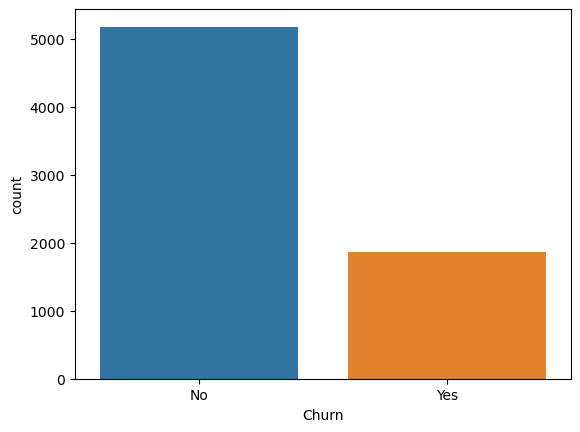

In [18]:
sns.countplot(data=df, x='Churn', hue='Churn')
plt.show()

## imblanced Data

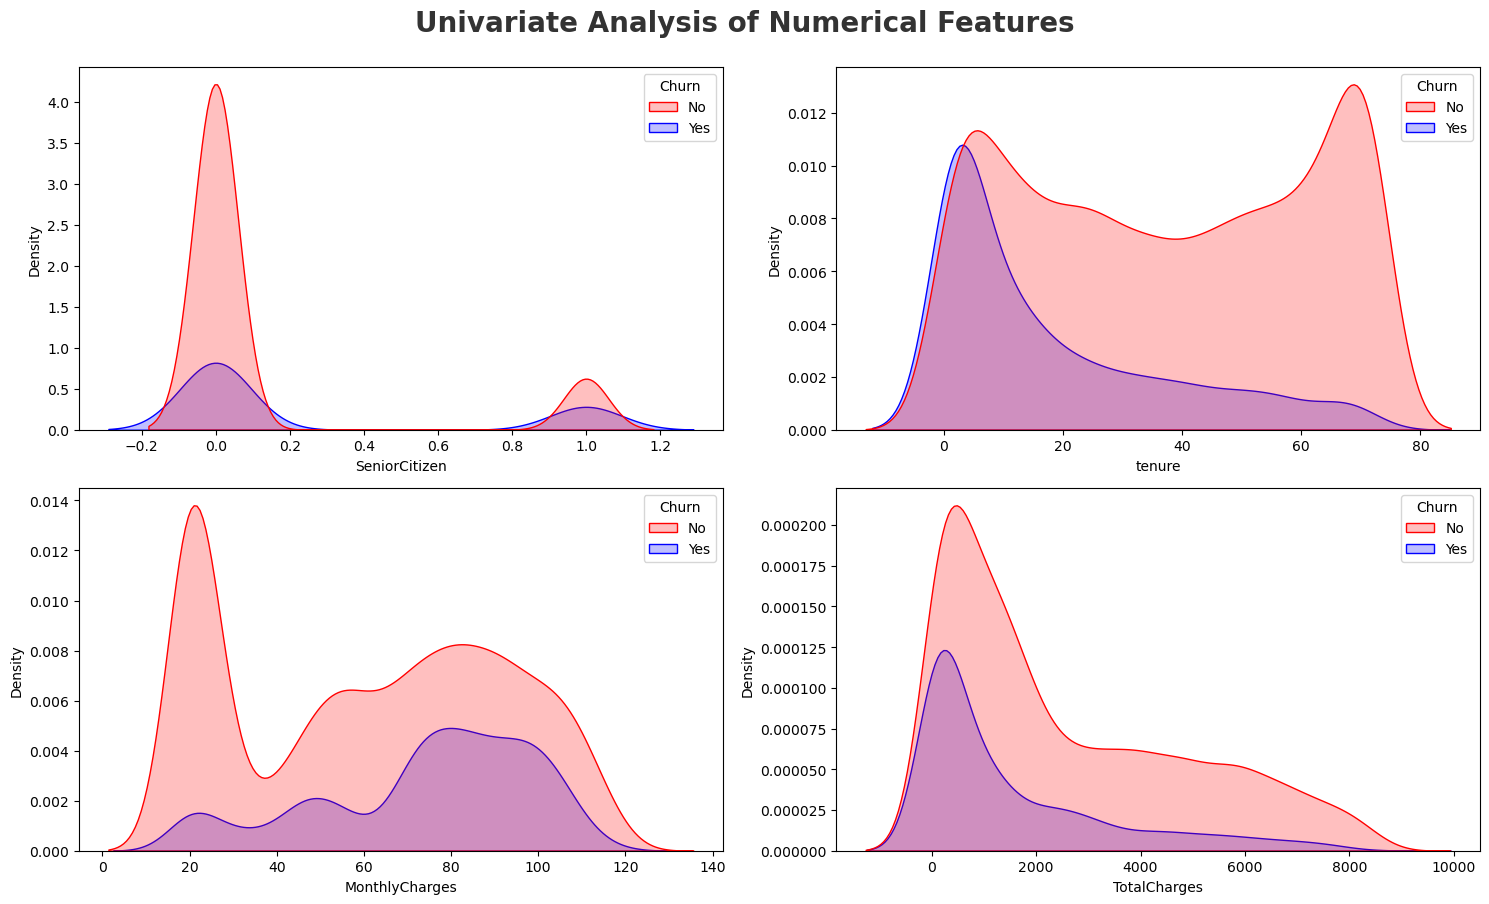

In [19]:
plt.figure(figsize=(15, 9))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range (0, len(numeric_features)):
    plt.subplot(2, 2, i+1)
    sns.kdeplot(x=df[numeric_features[i]], hue='Churn', data=df, shade=True, palette=['red', 'blue'])
    plt.xlabel(numeric_features[i])
    plt.tight_layout()
plt.show()    

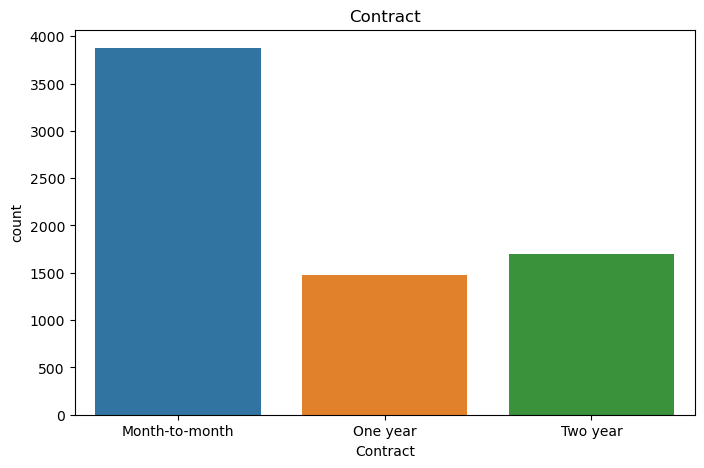

In [20]:
## Contract
plt.figure(figsize=(8, 5))
sns.countplot(x='Contract', data=df, hue='Contract')
plt.title('Contract')
plt.show()

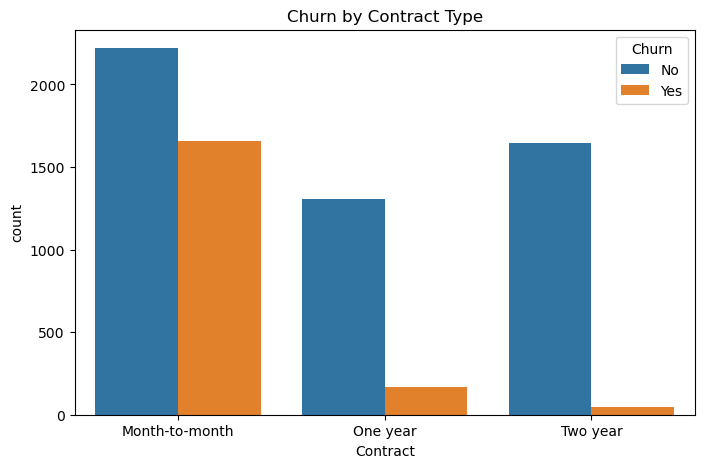

In [21]:
# Churn by Contract Type
plt.figure(figsize=(8, 5))
sns.countplot(x='Contract', data=df, hue='Churn')
plt.title('Churn by Contract Type')
plt.show()

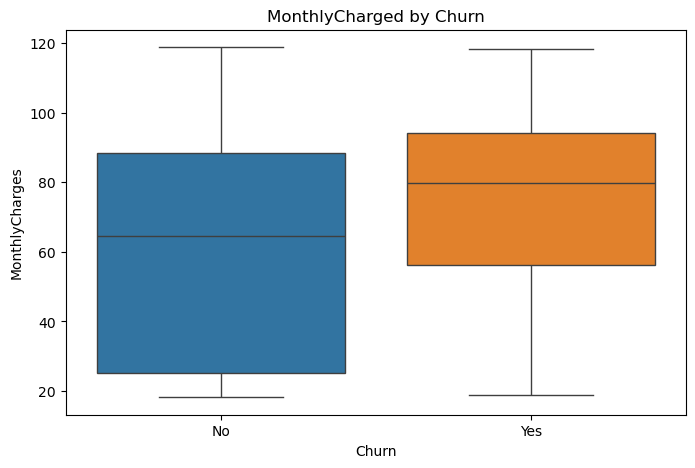

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges', hue='Churn', data=df)
plt.title('MonthlyCharged by Churn')
plt.show()

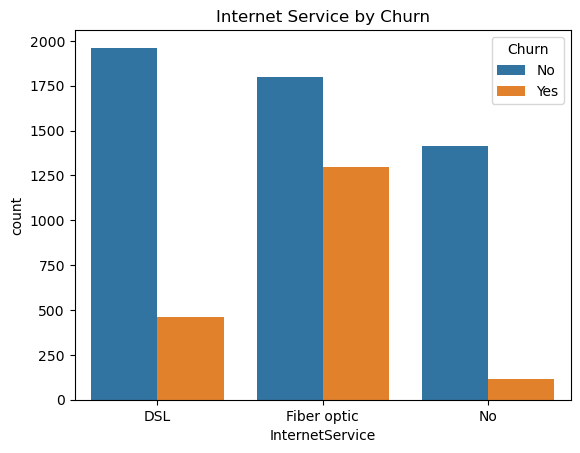

In [23]:
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title('Internet Service by Churn')
plt.show()

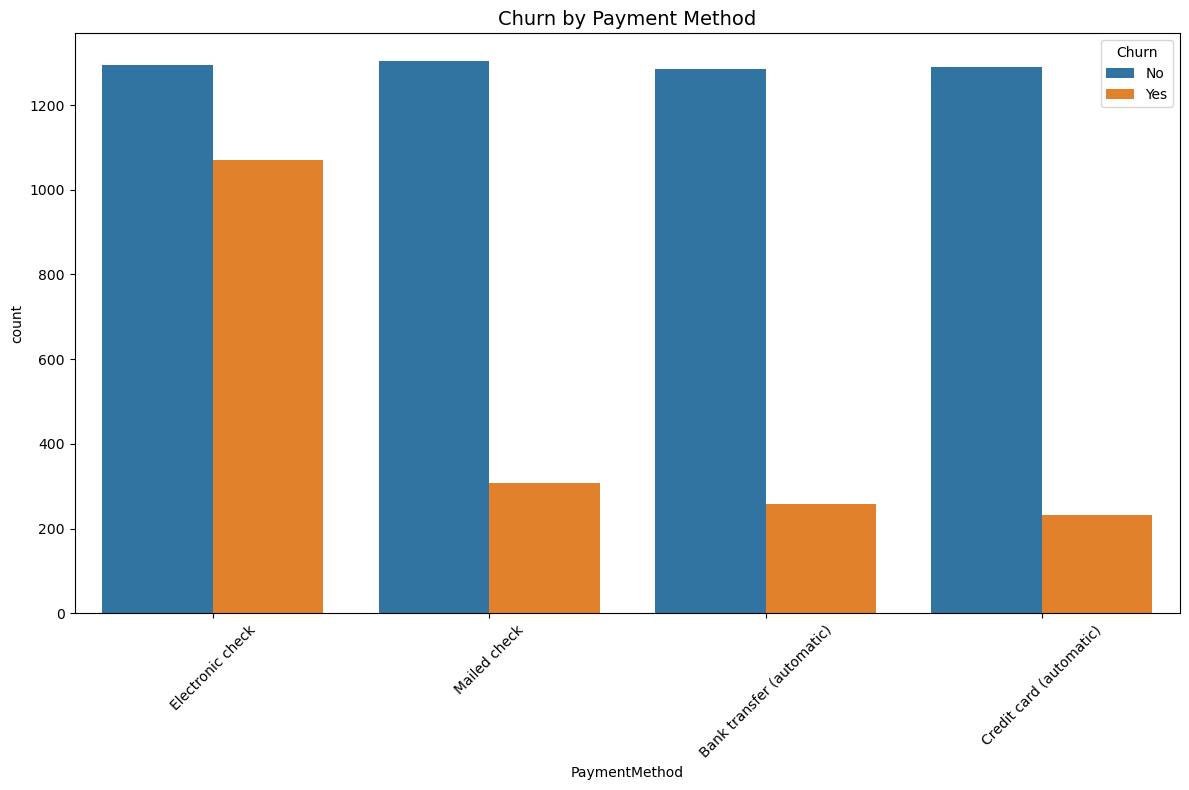

In [24]:
plt.figure(figsize=(12, 8))
sns.countplot(data=df, x='PaymentMethod', hue='Churn')
plt.title('Churn by Payment Method', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Correlation Heatmap of Numerical Features

In [25]:
numeric_features

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

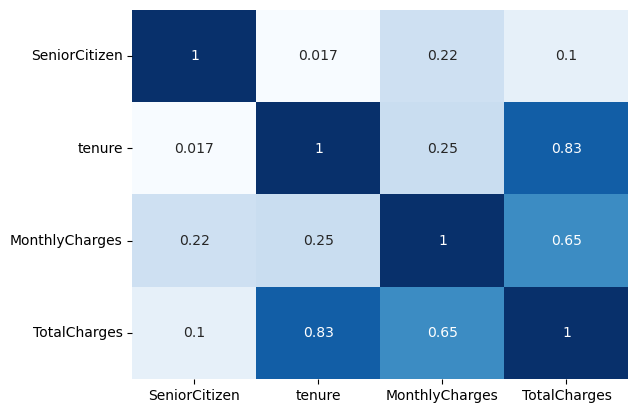

In [26]:
sns.heatmap(df[numeric_features].corr(), annot=True, cmap='Blues', cbar=False)
plt.show()

### Cleaning Categorical Columns

In [27]:
df.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [28]:
df['MultipleLines'].replace('No phone service', 'No', inplace=True)
df['InternetService'].replace('No internet service', 'No', inplace=True)
df['OnlineSecurity'].replace('No internet service', 'No', inplace=True)
df['OnlineBackup'].replace('No internet service', 'No', inplace=True)
df['DeviceProtection'].replace('No internet service', 'No', inplace=True)
df['TechSupport'].replace('No internet service', 'No', inplace=True)
df['StreamingTV'].replace('No internet service', 'No', inplace=True)
df['StreamingMovies'].replace('No internet service', 'No', inplace=True)

### Observation
### `Categories such as "No internet service" were replaced with "No", as the absence of internet service inherently implies the absence of related services. This avoids redundant feature representation and simplifies model interpretation.`

### Converting Yes/No Columns to Binary (0/1)

In [29]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


In [30]:
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
               'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    df[col] = df[col].map({'Yes':1, 'No':0})

In [31]:
df.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Converting gender(Male/Female) to binary(0/1) 

In [32]:
df['gender'] = df['gender'].map({'Male': 1, 'Female' : 0})

In [33]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,0,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,0,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0


### Splitting Features and Target Variables

In [34]:
X = df.drop(columns='Churn', axis=1)
y = df['Churn']

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True, stratify=y)

In [36]:
# Train Shape
X_train.shape, y_train.shape

((5634, 19), (5634,))

In [37]:
# Test Shape
X_test.shape, y_test.shape

((1409, 19), (1409,))

In [38]:
y_train.value_counts()  ##Imblanced Data

Churn
0    4139
1    1495
Name: count, dtype: int64

### Ecoding ===> OneHotEncoding

In [39]:
# data type before encoding
X_train.dtypes

gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService      object
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract             object
PaperlessBilling      int64
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
dtype: object

In [40]:
# Encoding
X_train = pd.get_dummies(data = X_train, columns=['InternetService', 'Contract', 'PaymentMethod'], dtype=int)

In [41]:
# Data Type after Enccoding
X_train.dtypes

gender                                       int64
SeniorCitizen                                int64
Partner                                      int64
Dependents                                   int64
tenure                                       int64
PhoneService                                 int64
MultipleLines                                int64
OnlineSecurity                               int64
OnlineBackup                                 int64
DeviceProtection                             int64
TechSupport                                  int64
StreamingTV                                  int64
StreamingMovies                              int64
PaperlessBilling                             int64
MonthlyCharges                             float64
TotalCharges                               float64
InternetService_DSL                          int32
InternetService_Fiber optic                  int32
InternetService_No                           int32
Contract_Month-to-month        

In [42]:
X_test = pd.get_dummies(data = X_test, columns=['InternetService', 'Contract', 'PaymentMethod'], dtype=int)

In [43]:
X_test.dtypes

gender                                       int64
SeniorCitizen                                int64
Partner                                      int64
Dependents                                   int64
tenure                                       int64
PhoneService                                 int64
MultipleLines                                int64
OnlineSecurity                               int64
OnlineBackup                                 int64
DeviceProtection                             int64
TechSupport                                  int64
StreamingTV                                  int64
StreamingMovies                              int64
PaperlessBilling                             int64
MonthlyCharges                             float64
TotalCharges                               float64
InternetService_DSL                          int32
InternetService_Fiber optic                  int32
InternetService_No                           int32
Contract_Month-to-month        

In [44]:
# Consolidation of columns
X_test = X_test.reindex(columns=X_train.columns)

In [45]:
X_test

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
437,1,0,1,1,72,1,1,1,1,1,...,0,1,0,0,0,1,0,1,0,0
2280,0,1,0,0,8,1,1,0,0,0,...,0,1,0,1,0,0,0,1,0,0
2235,0,0,1,1,41,1,1,1,1,1,...,1,0,0,0,1,0,0,1,0,0
4460,1,0,1,0,18,1,0,0,0,1,...,0,1,0,1,0,0,0,0,1,0
3761,0,0,1,0,72,1,1,1,1,1,...,1,0,0,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5143,0,0,1,1,49,1,0,1,1,1,...,1,0,0,0,1,0,0,0,0,1
4439,1,0,1,1,28,1,0,0,0,0,...,0,0,1,0,0,1,0,1,0,0
3857,1,0,0,0,5,1,0,0,0,0,...,0,0,1,1,0,0,1,0,0,0
4758,0,0,0,0,56,1,0,0,0,0,...,0,0,1,0,0,1,1,0,0,0


### Scaling Numerical Features Using MinMaxScaler

In [46]:
ft_scaling = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = MinMaxScaler()
X_train[ft_scaling] = scaler.fit_transform(X_train[ft_scaling])
X_test[ft_scaling] = scaler.transform(X_test[ft_scaling])

### Handling Imblanced Data Using SMOTE

In [47]:
#Imblanced Data before using SMOTE
y_train.value_counts() 

Churn
0    4139
1    1495
Name: count, dtype: int64

In [48]:
oversample = SMOTE(random_state=42)
X_train_smote,  y_train_smote = oversample.fit_resample(X_train, y_train)

In [49]:
# Data after using SMOTE
y_train_smote.value_counts() 

Churn
0    4139
1    4139
Name: count, dtype: int64

### Machine Learning Model 

### Support Vector Machine (SVM) Model

In [50]:
svc_model = SVC(random_state=42)
svc_model.fit(X_train_smote, y_train_smote)

SVC(random_state=42)

In [52]:
y_pred = svc_model.predict(X_train_smote)

# Accuracy Score by cross validation
acc_score = cross_val_score(estimator=svc_model, X=X_train_smote, y=y_train_smote, n_jobs=-1, cv=5, scoring='accuracy')
print(f'Accuracy Scores using cross validation --- \n', acc_score)

Accuracy Scores using cross validation --- 
 [0.77958937 0.7705314  0.84480676 0.81691843 0.80664653]


In [53]:
## Mean of Accuracy Score
acc_score.mean()

0.8036984981829327

In [54]:
acc_model = svc_model.score(X_test, y_test)
print(f'Accuracy Model : ', acc_model)

Accuracy Model :  0.7615330021291696


### Random Forest (RF) Model

In [56]:
RF_model = RandomForestClassifier()
RF_model.fit(X_train_smote, y_train_smote)

RandomForestClassifier()

In [58]:
y_pred = RF_model.predict(X_train_smote)

# Accuracy Score by cross validation
acc_score = cross_val_score(estimator=RF_model, X=X_train_smote, y=y_train_smote, n_jobs=-1, cv=5, scoring='accuracy')
print(f'Accuracy Scores using cross validation --- \n', acc_score.mean())

Accuracy Scores using cross validation --- 
 0.8400610067574471


In [60]:
acc_model_RF = RF_model.score(X_test, y_test)
print(f'Accuracy Model Random Forest : ', acc_model_RF)

Accuracy Model Random Forest :  0.7700496806245565


### Visualizing Features Importance From Random Forest

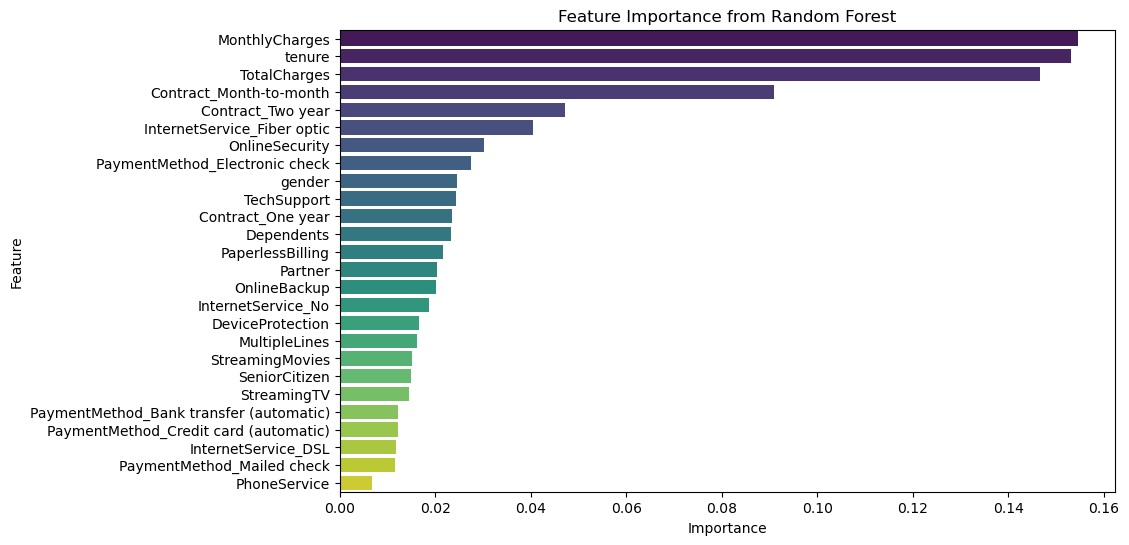

In [83]:
feature_importance = RF_model.feature_importances_
df_feat_importance = pd.DataFrame({'feature':X_train_smote.columns, 'Importance':feature_importance})

#sort features importances
df_feat_importance=df_feat_importance.sort_values(by='Importance', ascending=False)

# barplot
plt.figure(figsize=(10, 6))
sns.barplot(x=df_feat_importance['Importance'], y=df_feat_importance['feature'], palette='viridis')
plt.title('Feature Importance from Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [86]:
pickle.dump(RF_model, open('Random_Forest_model.pkl', 'wb'))